### Seleção de canal e decimação em um receptor SDR
Aluno: Marcos Eduardo, 121210541

### 1. Motivação

Um receptor definido por software digitaliza uma banda larga de 1,92 MHz contendo vários canais adjacentes. Após a conversão descendente digital (DDC) para banda base, é preciso isolar o canal de interesse, que ocupa cerca de ±100 kHz, rejeitando o canal adjacente centrado em 200 kHz, e depois decimar por 4 para reduzir a taxa de amostragem antes do bloco seguinte, um classificador de modulação embarcado. Há ainda um interferente forte em 450 kHz que, se não for filtrado, dobra exatamente sobre o canal útil ao decimar. Como o classificador decide sobre a constelação I/Q, o filtro de seleção não pode distorcer a fase dentro do canal.

**Dados fornecidos:**

| Parâmetro | Valor |
|---|---|
| Taxa de amostragem $F_s$ | 1,92 MHz |
| Fator de decimação | 4 (nova taxa: 480 kHz) |
| Passagem | até 100 kHz |
| Rejeição | a partir de 200 kHz (canal adjacente) |
| Ondulação na passagem | 0,1 dB |
| Atenuação na rejeição | 60 dB |

##### 1.1 Sistema SDR

SDR é uma arquitetura de sistema de rádio em que funções de hardware como: sintonia, filtragem e demodulação são implementadas em software, o sinal é digitalizado o mais cedo possível por um conversor A/D, tornando o sistema reconfigurável.

Na janela de 1,92 MHz há vários canais transmitindo lado a lado, como estações de rádio vizinhas. O DDC escolhe um deles, mas os vizinhos continuam presentes no sinal digitalizado.

##### 1.2 Decimação 

Decimar por $M$ reduz a taxa de amostragem:

$$F_s' = \frac{F_s}{M} = \frac{1{,}92 \text{ MHz}}{4} = 480 \text{ kHz}$$

A nova taxa só representa frequências até $F_s'/2$. Qualquer energia acima desse limite dobra para dentro da banda útil de forma irreversível exigindo um filtro obrigatoriamente antes da decimação.

Na prática, $M$ é escolhido como potência de 2, implementando em cascata, reduzindo o custo computacional. Neste projeto, $M = 4 = 2^2$.

##### 2.1 Linearidade na constelação I/Q

Se o filtro distorcer a fase, os pontos da constelação giram e se espalham de forma dependente da frequência, isso obriga o uso de um filtro de fase linear.

##### 2.2 O interferente

O interferente em 450 kHz é um sinal forte fora do canal. Após a decimação e com $F_s' = 480$ kHz:

$$f_{alias} = 450 - 480 = -30 \text{ kHz}$$

Ele reaparece em $\pm 30$ kHz, dentro do canal útil de forma irreversível, que obriga o filtro a existir antes do decimador.


##### 2.3 Ondulação na passagem (0,1 dB)

Na banda de passagem, o ganho ideal é 1, mas todo filtro real oscila. A especificação limita essa oscilação: o ganho deve ficar entre $1 - \delta_p$ e $1 + \delta_p$, com

$$20\log_{10}\frac{1+\delta_p}{1-\delta_p} = 0{,}1 \text{ dB} \quad\Longrightarrow\quad \delta_p \approx 0{,}0058$$

É um requisito apertado, e com razão: qualquer ondulação no ganho deforma as amplitudes dos símbolos da constelação. Um perfil bem plano na passagem preserva o sinal exatamente como ele chegou.

##### 2.4 Atenuação de 60 dB

$$-20 \log_{10}(10^{-60/20}) = 10^{-3} = 0.001 $$

Comparando com as atenuações típicas de cada janela:

| Janela | Atenuação típica |
|---|---|
| Retangular | ~21 dB |
| Hanning | ~44 dB |
| Hamming | ~53 dB |
| Blackman | ~74 dB |
| Kaiser | ajustável |

A Janela de Kaiser é a melhor escolha, o parâmetro $\beta$ é calculado a partir da atenuação exigida, permitindo atender exatamente os 60 dB com a menor ordem possível dentre os métodos de janelamento.

### 3. Especificações do sinal

Com os dados fornecidos pelo projeto, as especificações do sinal são:

In [1]:
import numpy as np

Fs = 1920000
D  = 4                
np.random.seed(9)
t = np.arange(0, 4e-3, 1/Fs)
util  = np.exp(1j*2*np.pi*30000*t)
util *= (1 + 0.3*np.sin(2*np.pi*5000*t))
adj   = 8.0*np.exp(1j*2*np.pi*200000*t)
alias = 6.0*np.exp(1j*2*np.pi*450000*t)
ruido = 0.01*(np.random.randn(len(t)) + 1j*np.random.randn(len(t)))
x = util + adj + alias + ruido

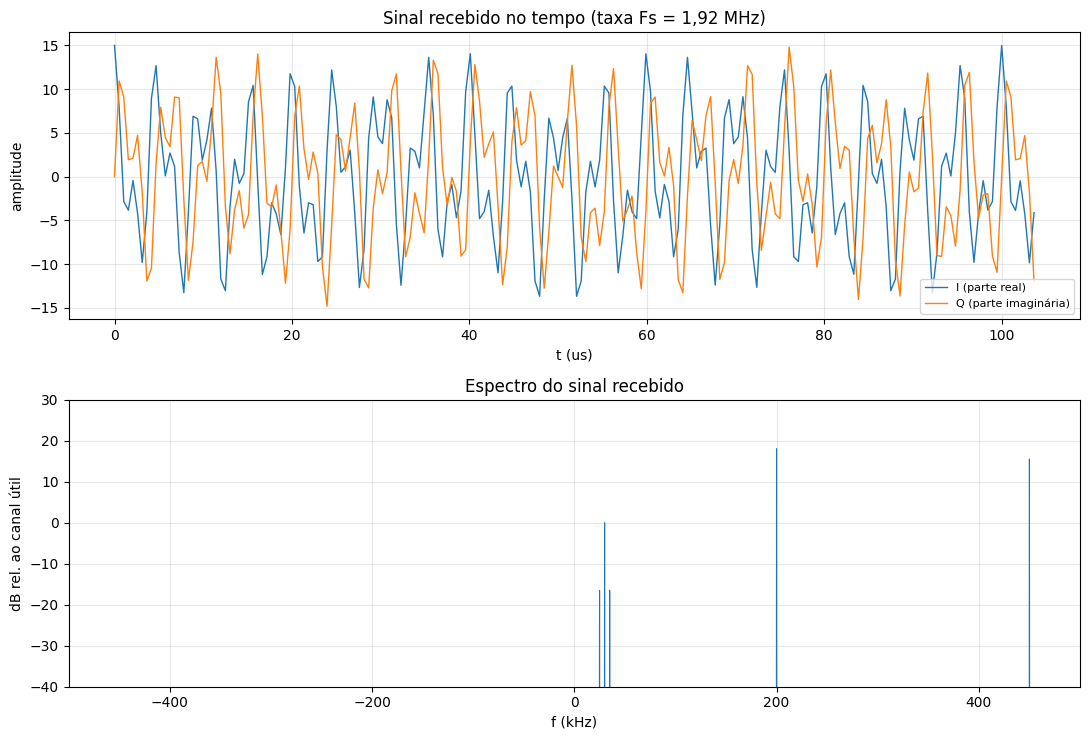

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# espectro do sinal recebido, ainda na taxa original Fs.
X   = np.abs(np.fft.fftshift(np.fft.fft(x)))/len(x)
fx  = np.fft.fftshift(np.fft.fftfreq(len(x), 1/Fs))
ref = X[np.argmin(np.abs(fx - 30e3))]
XdB = 20*np.log10(X/ref + 1e-300)

fig, ax = plt.subplots(2, 1, figsize=(11, 7.5))

# Plot no tempo limpo (apenas os dados reais e imaginários)
ax[0].plot(t[:200]*1e6, x[:200].real, lw=1, label='I (parte real)')
ax[0].plot(t[:200]*1e6, x[:200].imag, lw=1, label='Q (parte imaginária)')
ax[0].set_title('Sinal recebido no tempo (taxa Fs = 1,92 MHz)')
ax[0].set_xlabel('t (us)'); ax[0].set_ylabel('amplitude')

# Plot no domínio da frequência
ax[1].plot(fx/1e3, XdB, lw=.8)
ax[1].set_title('Espectro do sinal recebido')
ax[1].set_xlabel('f (kHz)'); ax[1].set_ylabel('dB rel. ao canal útil')
ax[1].set_xlim(-500, 500)
ax[1].set_ylim(-40, 30)

for a_ in ax: a_.grid(alpha=.3)
ax[0].legend(fontsize=8)

plt.tight_layout()
plt.show()

### 4. Objetivo

Projetar o passa-baixas de seleção de canal, decimar por 4 sem que o canal adjacente nem o interferente de alta frequência dobrem sobre o canal útil, e demonstrar o ganho de eficiência obtido com a implementação polifásica.

**Tipo de filtro indicado**: FIR passa-baixas de fase linear

### 5. Tarefas

##### 5.1. Determine as especificações do filtro e normalize as frequências em relação a Fs.

As bordas para o filtro são: a frequência de passagem vai até 100 kHz; o canal adjacente está centrado em 200 kHz, então a rejeição começa em 200 kHz e restam 100 kHz de transição.

Normalização

Com $\omega = 2\pi f / F_s$ em rad/amostra e $f/F_s$ em ciclos/amostra:

$$\omega_p = 2\pi\frac{100}{1920} = 0{,}3272 \qquad \omega_s = 2\pi\frac{200}{1920} = 0{,}6545 \qquad \Delta\omega = \omega_s - \omega_p = 0{,}3273$$

In [3]:
fp = 100e3  #Passagem
fr = 200e3  #Rejeição
op = 0.1    #Ondulação
ar = 60.0   #Atenuação

sigma_1 = (10**(op/20) - 1) / (10**(op/20) + 1)
sigma_2 = 10**(-ar/20)
wp      = 2*np.pi*fp/Fs
ws      = 2*np.pi*fr/Fs 

Fs2   = Fs/D    
f_nyq = Fs2/2   
f_int = 450e3

print(f"wp = {wp:.4f}")
print(f"ws = {ws:.4f}")
print(f"transicao: dw = {ws-wp:.4f}")
print(f"sigma_1 = {sigma_1:.4f} e sigma_2 = {sigma_2:.4f}")
print()
print(f"Nova Nyquist = {f_nyq/1e3:.0f} kHz")
print(f"Interferente = {f_int/1e3:.0f} kHz")

wp = 0.3272
ws = 0.6545
transicao: dw = 0.3272
sigma_1 = 0.0058 e sigma_2 = 0.0010

Nova Nyquist = 240 kHz
Interferente = 450 kHz


**Especificações do filtro, consolidadas**

| Ponto | $f$ (kHz) | $f/F_s$ | $\omega = 2\pi f/F_s$ (rad/amostra) | 
|---|---|---|---|
| Borda de passagem | 100 | 0,052083 | 0,3272 |
| Borda de rejeição | 200 | 0,104167 | 0,6545 |
| Transição $\Delta$ | 100 | 0,052083 | 0,3272 | — |
| Nova Nyquist $F_s'/2$ | 240 | 0,125000 | 0,7854 $(=\pi/4)$ |
| Interferente | 450 | 0,234375 | 1,4726 |

##### 5.2 Justifique a escolha do tipo de filtro e do método de projeto, considerando fase, atraso de grupo e custo.

O classificador de modulação decide sobre a constelação I/Q, onde a informação está na amplitude e na fase. Um filtro IIR tem fase não linear, o atraso de grupo varia com a frequência, distorcendo a constelação. Um FIR com coeficientes simétricos garante fase exatamente linear e atraso de grupo constante, o sinal inteiro é apenas atrasado, sem deformações. Isso torna o FIR ideal para este projeto.

Escolhi k=0 e M ímpar porque é a combinação que garante fase linear, atraso de grupo constante e inteiro, e sem nenhuma restrição de frequência, ideal para passa-baixas.

Das janelas vistas em aula, a Kaiser ajusta o parâmetro $\beta$ a partir da atenuação exigida, entregando exatamente o necessário com a menor ordem possível entre os métodos de janelamento.

O FIR exige 93 coeficientes contra ordem 6 de um IIR elíptico. Mas como o filtro precede uma decimação por 4 e após decomposição polifásica reduz o custo real em 4×. Além disso, obter fase linear com um IIR exigiria um equalizador adicional, anulando sua vantagem. O custo extra do FIR é, na prática, inexistente.

##### 5.3. Projete o filtro e informe a ordem (ou número de coeficientes) e os parâmetros obtidos.

In [4]:
#Encontrando o valor de delta, no nosso caso delta = sigma_2.
delta = min(sigma_1, sigma_2)

amp_int = 6.0                                   
A_adj   = -20*np.log10(delta)
A_int   = -20*np.log10(delta) + 20*np.log10(amp_int)
A       = max(A_adj, A_int)

# Beta pela formula do slide para Janela Kaiser
if   A > 50:  
    beta = 0.1102*(A - 8.7)
elif A >= 21: 
    beta = 0.5842*(A - 21)**0.4 + 0.07886*(A - 21)
else:         
    beta = 0.0

#Comprimento M = (A - 7,95)/(2,285*dw) + 1
dw = ws - wp
M  = int(np.ceil(((A - 7.95) / (2.285*dw)) + 1))
if M % 2 == 0: 
    M += 1                   

#Bessel modificada de 1a especie, ordem zero, pela serie
def I0(z, terms=50):
    z = np.asarray(z, dtype=float)
    s = np.ones_like(z) 
    termo = np.ones_like(z)
    for k in range(1, terms):
        termo = termo * (z/2.0)**2 / (k*k)
        s = s + termo
    return s

#Ajustando as equações da janela kaiser
n     = np.arange(M)                    
alpha = (M - 1)/2
fc    = (fp + fr)/2.0                   
wc    = 2*np.pi*fc/Fs
m     = n - alpha

hd  = np.where(m == 0, wc/np.pi,
               np.sin(wc*np.where(m == 0, 1, m)) / (np.pi*np.where(m == 0, 1, m)))
wn = I0(beta*np.sqrt(np.maximum(0, 1 - (1 - 2*n/(M - 1))**2))) / I0(np.array(beta))

h = hd * wn

# Impressão direta dos valores
print(f"Tolerância (delta) : {delta:.6f}")
print(f"Atenuação p/ o adjacente : {A_adj:.2f} dB")
print(f"Atenuação p/ o interferente : {A_int:.2f} dB")
print(f"Atenuação de projeto (A) : {A:.2f} dB")
print(f"Banda trans. (dw)  : {dw:.4f} rad/amostra")
print(f"Parâmetro (beta)   : {beta:.4f}")
print(f"Comprimento (M)    : {M} coeficientes")
print(f"Atraso (alpha)     : {alpha:.0f} amostras = {alpha/Fs*1e6:.2f} us")

Tolerância (delta) : 0.001000
Atenuação p/ o adjacente : 60.00 dB
Atenuação p/ o interferente : 75.56 dB
Atenuação de projeto (A) : 75.56 dB
Banda trans. (dw)  : 0.3272 rad/amostra
Parâmetro (beta)   : 7.3683
Comprimento (M)    : 93 coeficientes
Atraso (alpha)     : 46 amostras = 23.96 us


In [5]:
Hd  = lambda fq: np.exp(-1j*2*np.pi*np.outer(np.atleast_1d(fq), n)/Fs) @ h
rip = 20*np.log10(np.abs(Hd(np.linspace(0, fp, 500))))

print(f"Ganho DC (0 Hz)   : {20*np.log10(abs(Hd(0.0))[0]):+.4f} dB")
print(f"Ripple Passagem   : {rip.max() - rip.min():.4f} dB")
print(f"Atenuação Rejeição: {-20*np.log10(abs(Hd(fr))[0]):.2f} dB")
print(f"Atenuação Int.    : {-20*np.log10(abs(Hd(f_int))[0]):.2f} dB")

Ganho DC (0 Hz)   : +0.0007 dB
Ripple Passagem   : 0.0025 dB
Atenuação Rejeição: 97.08 dB
Atenuação Int.    : 92.19 dB


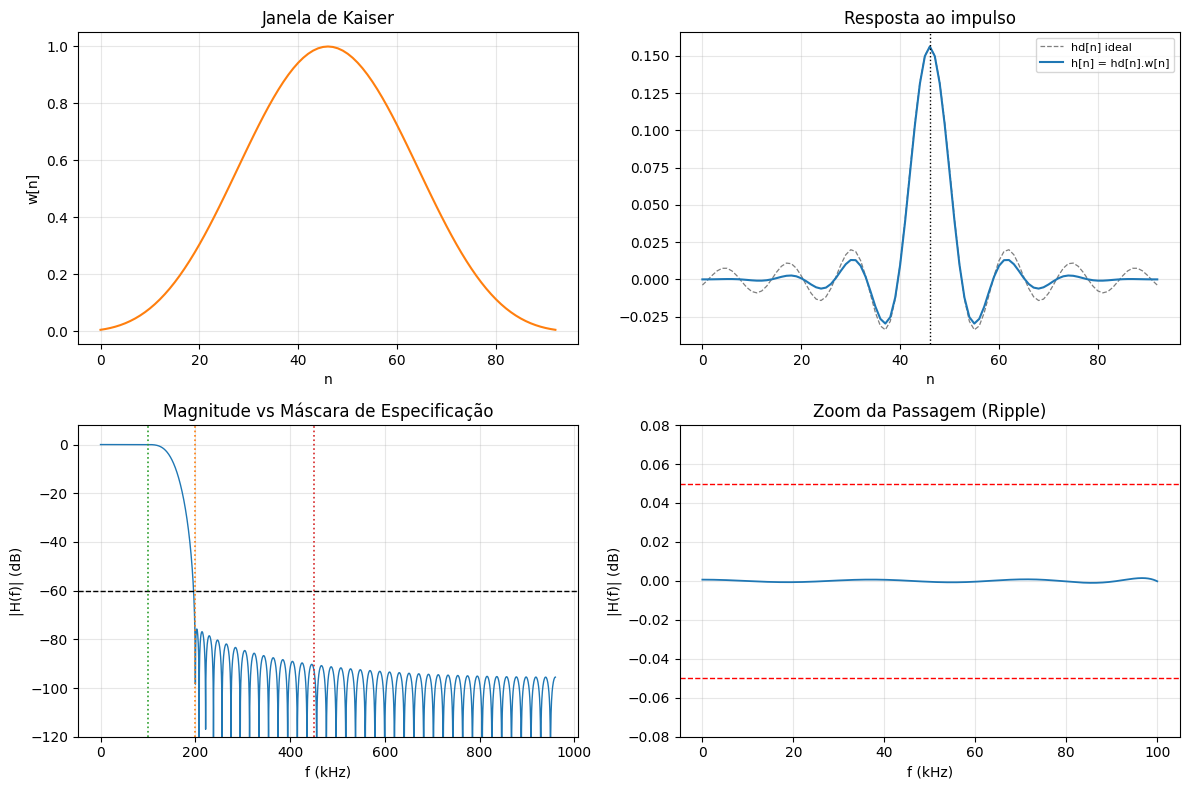

In [6]:
fg  = np.linspace(0, Fs/2, 4000)
HdB = 20*np.log10(np.abs(Hd(fg)) + 1e-300)
fpb = np.linspace(0, fp, 800)
PdB = 20*np.log10(np.abs(Hd(fpb)))

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

#A janela: e ela que define quanto os lobulos laterais caem
ax[0,0].plot(n, wn, lw=1.5, color='tab:orange')
ax[0,0].set_title('Janela de Kaiser')
ax[0,0].set_xlabel('n'); ax[0,0].set_ylabel('w[n]'); ax[0,0].grid(alpha=.3)

#O filtro e o produto do sinc ideal pela janela
ax[0,1].plot(n, hd, lw=.9, ls='--', color='tab:gray', label='hd[n] ideal')
ax[0,1].plot(n, h,  lw=1.5, color='tab:blue',         label='h[n] = hd[n].w[n]')
ax[0,1].axvline(alpha, ls=':', c='k', lw=1)
ax[0,1].set_title('Resposta ao impulso')
ax[0,1].set_xlabel('n'); ax[0,1].legend(fontsize=8); ax[0,1].grid(alpha=.3)

#Magnitude em dB contra a mascara de especificacao (Limpo)
ax[1,0].plot(fg/1e3, HdB, lw=1, color='tab:blue')
ax[1,0].axhline(-ar, ls='--', c='k', lw=1) # Linha limite de atenuação
for f0, cor in [(fp, 'tab:green'), (fr, 'tab:orange'), (f_int, 'tab:red')]:
    ax[1,0].axvline(f0/1e3, ls=':', c=cor, lw=1.2) # Linhas das frequências de corte e interferente
ax[1,0].set_title('Magnitude vs Máscara de Especificação')
ax[1,0].set_xlabel('f (kHz)'); ax[1,0].set_ylabel('|H(f)| (dB)')
ax[1,0].set_ylim(-120, 8); ax[1,0].grid(alpha=.3)

#Zoom da passagem (Limpo)
lim = op/2
ax[1,1].plot(fpb/1e3, PdB, lw=1.3, color='tab:blue')
ax[1,1].axhline(+lim, ls='--', c='r', lw=1) # Linha limite superior de ondulação
ax[1,1].axhline(-lim, ls='--', c='r', lw=1) # Linha limite inferior de ondulação
ax[1,1].set_title('Zoom da Passagem (Ripple)')
ax[1,1].set_xlabel('f (kHz)'); ax[1,1].set_ylabel('|H(f)| (dB)')
ax[1,1].set_ylim(-lim*1.6, lim*1.6); ax[1,1].grid(alpha=.3)

plt.tight_layout()
plt.show()

##### 5.4. Apresente os gráficos de magnitude (dB), fase e atraso de grupo, com as bordas das faixas marcadas.

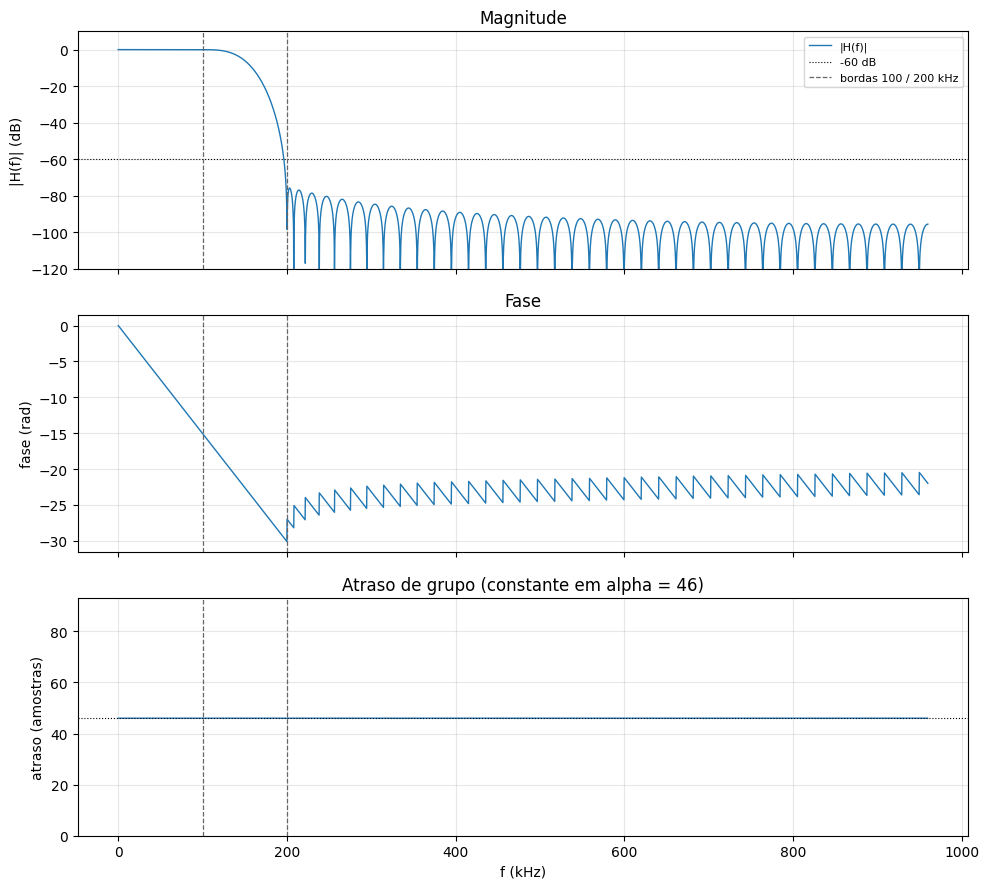

atraso de grupo na passagem: min = 46.0000, max = 46.0000 amostras


In [7]:
from scipy.signal import group_delay

fg = np.linspace(0, Fs/2, 4000)
Hg = Hd(fg)

fig, ax = plt.subplots(3, 1, figsize=(10, 9), sharex=True)

# magnitude em dB
ax[0].plot(fg/1e3, 20*np.log10(np.abs(Hg) + 1e-300), lw=1, label='|H(f)|')
ax[0].axhline(-ar, ls=':', c='k', lw=.8, label=f'-{ar:.0f} dB')
ax[0].set_ylabel('|H(f)| (dB)'); ax[0].set_ylim(-120, 10); ax[0].set_title('Magnitude')

# fase: reta na passagem; os dentes na rejeicao sao os nulos de |H|
ax[1].plot(fg/1e3, np.unwrap(np.angle(Hg)), lw=1)
ax[1].set_ylabel('fase (rad)'); ax[1].set_title('Fase')

# atraso de grupo: constante e igual a alpha
wg, gd = group_delay((h, 1), w=4000)
ax[2].plot(wg/np.pi*(Fs/2)/1e3, gd, lw=1)
ax[2].axhline(alpha, ls=':', c='k', lw=.8)
ax[2].set_ylabel('atraso (amostras)'); ax[2].set_ylim(0, M)
ax[2].set_xlabel('f (kHz)'); ax[2].set_title(f'Atraso de grupo (constante em alpha = {alpha:.0f})')

# bordas das faixas em todos os paineis
for i, a_ in enumerate(ax):
    a_.axvline(fp/1e3, ls='--', c='0.4', lw=.9, label='bordas 100 / 200 kHz' if i == 0 else None)
    a_.axvline(fr/1e3, ls='--', c='0.4', lw=.9)
    a_.grid(alpha=.3)
ax[0].legend(fontsize=8, loc='upper right')

plt.tight_layout(); plt.show()

pb = fg <= fp
print(f"atraso de grupo na passagem: min = {gd[wg/np.pi*(Fs/2) <= fp].min():.4f}, "
      f"max = {gd[wg/np.pi*(Fs/2) <= fp].max():.4f} amostras")

##### 5.5. Gere o sinal de teste da Seção 3, aplique o filtro e mostre o resultado no tempo e no espectro, antes e depois.

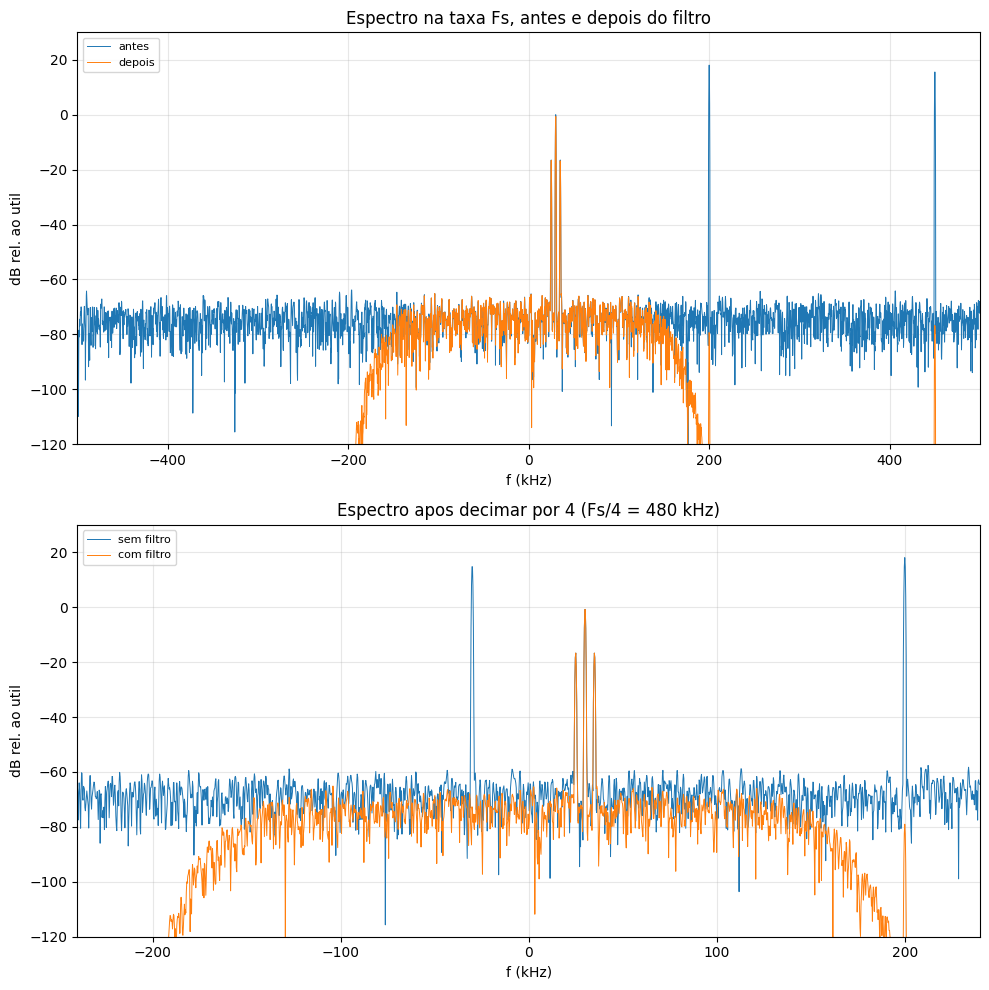

sem filtro: alias em -30 kHz = +15.56 dB rel. ao util
com filtro: alias em -30 kHz = -71.86 dB rel. ao util
com filtro: adjacente 200 kHz = -78.20 dB rel. ao util


In [8]:
from scipy.signal.windows import blackmanharris

def espectro(sig, fs, ntr=0):
    """Espectro em amplitude. ntr descarta o transiente do filtro; a janela de
    Blackman-Harris evita que o vazamento espectral mascare os niveis baixos."""
    s  = sig[ntr:]
    jw = blackmanharris(len(s))
    X  = np.abs(np.fft.fftshift(np.fft.fft(s*jw)))/np.sum(jw)
    f  = np.fft.fftshift(np.fft.fftfreq(len(s), 1/fs))
    return f, X

v     = np.convolve(x, h)[:len(x)]      # filtra na taxa alta
y_dir = v[::D]                          # decima: guarda 1 de cada 4
Fs2   = Fs/D
ntr   = int(np.ceil(M/D))               # amostras de transiente na saida

f_in,  X_in  = espectro(x,      Fs)
f_fil, X_fil = espectro(v,      Fs,  M)
f_sem, X_sem = espectro(x[::D], Fs2, ntr)   # decimado SEM filtrar
f_com, X_com = espectro(y_dir,  Fs2, ntr)   # decimado COM filtro
ref = X_in[np.argmin(np.abs(f_in - 30e3))]  # 0 dB = canal util na entrada

fig, ax = plt.subplots(2, 1, figsize=(10, 10))

ax[0].plot(f_in/1e3,  20*np.log10(X_in/ref  + 1e-300), lw=.7, label='antes')
ax[0].plot(f_fil/1e3, 20*np.log10(X_fil/ref + 1e-300), lw=.7, label='depois')
ax[0].set_xlim(-500, 500); ax[0].set_ylim(-120, 30)
ax[0].set_title('Espectro na taxa Fs, antes e depois do filtro')

ax[1].plot(f_sem/1e3, 20*np.log10(X_sem/ref + 1e-300), lw=.7, label='sem filtro')
ax[1].plot(f_com/1e3, 20*np.log10(X_com/ref + 1e-300), lw=.7, label='com filtro')
ax[1].set_xlim(-240, 240); ax[1].set_ylim(-120, 30)
ax[1].set_title('Espectro apos decimar por 4 (Fs/4 = 480 kHz)')

for a_ in ax[:2]:
    a_.set_xlabel('f (kHz)'); a_.set_ylabel('dB rel. ao util')

for a_ in ax: a_.legend(fontsize=8); a_.grid(alpha=.3)
plt.tight_layout(); plt.show()

nivel = lambda f, X, f0: X[np.argmin(np.abs(f - f0))]
u_com = nivel(f_com, X_com, 30e3)
u_sem = nivel(f_sem, X_sem, 30e3)
print(f"sem filtro: alias em -30 kHz = {20*np.log10(nivel(f_sem, X_sem, -30e3)/u_sem):+.2f} dB rel. ao util")
print(f"com filtro: alias em -30 kHz = {20*np.log10(nivel(f_com, X_com, -30e3)/u_com):+.2f} dB rel. ao util")
print(f"com filtro: adjacente 200 kHz = {20*np.log10(nivel(f_com, X_com, 200e3)/u_com):+.2f} dB rel. ao util")

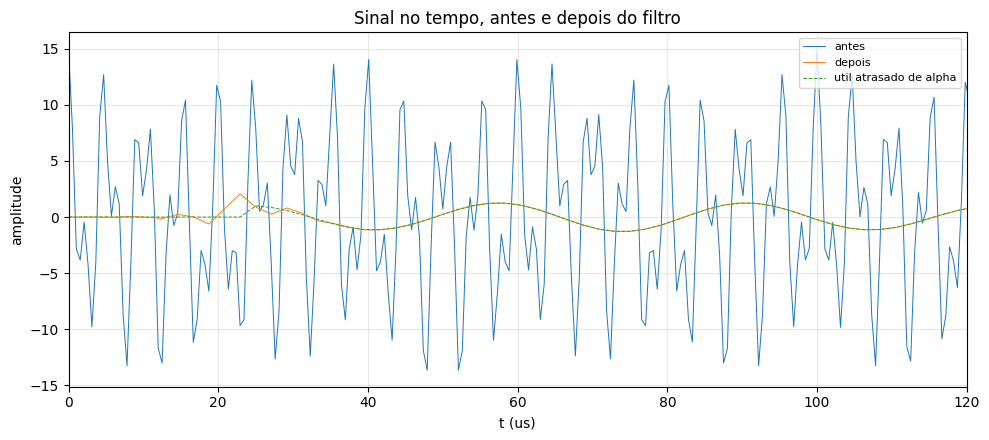

transiente: 24 amostras = 50.0 us
erro max apos o transiente: 1.62e-02


In [9]:
# Resultado no tempo: entrada, saida filtrada e decimada, e o canal util
t2       = t[::D]
util_ref = np.concatenate([np.zeros(int(alpha), dtype=complex), util])[:len(x)][::D]

fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(t*1e6,  x.real,        lw=.7, label='antes')
ax.plot(t2*1e6, y_dir.real,    lw=.7, label='depois')
ax.plot(t2*1e6, util_ref.real, lw=.7, ls='--', label='util atrasado de alpha')

ax.set_xlim(0, 120)
ax.set_title('Sinal no tempo, antes e depois do filtro')
ax.set_xlabel('t (us)'); ax.set_ylabel('amplitude')
ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

print(f"transiente: {ntr} amostras = {ntr/Fs2*1e6:.1f} us")
print(f"erro max apos o transiente: {np.max(np.abs(y_dir[ntr:] - util_ref[ntr:])):.2e}")

##### 5.6. Preencha a tabela de métricas da Seção 6 e verifique o critério de aprovação da Seção 7.

In [10]:
# Métricas medidas
r200  = -20*np.log10(abs(Hd(fr))[0])
a450  = -20*np.log10(abs(Hd(f_int))[0])
rip   = 20*np.log10(np.abs(Hd(np.linspace(0, fp, 600))))
ondul = rip.max() - rip.min()
alias = 20*np.log10(nivel(f_com, X_com, -30e3)/u_com)
adjr  = 20*np.log10(nivel(f_com, X_com, 200e3)/u_com)

# Multiplicações por amostra de saída
mult_dir = M * D                  
mult_pol = M + (-M) % D         

ok = lambda cond: 'OK' if cond else 'FALHA'
print("------- Métricas -------")
print(f"Coeficientes      : {M}")
print(f"Atraso de grupo   : {alpha:.0f} amostras ({alpha/Fs*1e6:.2f} us)")
print(f"Rejeição 200 kHz  : {r200:.2f} dB")
print(f"Atenuação 450 kHz : {a450:.2f} dB")
print(f"Aliasing no canal : {alias:+.2f} dB")
print(f"Eficiência (mults): Direta {mult_dir} x Polifásica {mult_pol} ({mult_dir/mult_pol:.1f}x)")

print("\n------- Aprovação -------")
print(f"Rejeição (>= 60 dB) : {r200:6.2f} dB  [{ok(r200 >= 60)}]")
print(f"Alias (<= -60 dB)   : {alias:+6.2f} dB  [{ok(alias <= -60)}]")
print(f"Ripple (<= 0.1 dB)  : {ondul:6.4f} dB  [{ok(ondul <= 0.1)}]")
print(f"Resíduo adjacente   : {adjr:+6.2f} dB")

------- Métricas -------
Coeficientes      : 93
Atraso de grupo   : 46 amostras (23.96 us)
Rejeição 200 kHz  : 97.08 dB
Atenuação 450 kHz : 92.19 dB
Aliasing no canal : -71.86 dB
Eficiência (mults): Direta 372 x Polifásica 96 (3.9x)

------- Aprovação -------
Rejeição (>= 60 dB) :  97.08 dB  [OK]
Alias (<= -60 dB)   : -71.86 dB  [OK]
Ripple (<= 0.1 dB)  : 0.0025 dB  [OK]
Resíduo adjacente   : -78.20 dB


**Tabela de métricas**

| Métrica a reportar | Valor obtido |
|---|---|
| Número de coeficientes e atraso de grupo (amostras e µs) | 93 coeficientes; $\alpha = 46$ amostras = 23,96 µs |
| Rejeição medida em 200 kHz, no canal adjacente (dB) | 97,08 dB |
| Atenuação em 450 kHz e nível do aliasing sobre o canal | 92,19 dB de atenuação; alias em −71,9 dB abaixo do útil |
| Multiplicações por amostra de saída: direta versus polifásica | 372 contra 96 — ganho de 3,9× |

**Critério de aprovação**

| Critério | Exigido | Obtido | |
|---|---|---|---|
| Rejeição em 200 kHz | ≥ 60 dB | 97,08 dB | OK |
| Componente de 450 kHz dobrada sobre o útil | ≤ −60 dB rel. ao útil | −71,9 dB | OK |
| Passagem plana até 100 kHz | dentro de ±0,1 dB | 0,0025 dB pico a pico | OK |

##### Implemente a decimação de forma polifásica (decompondo o FIR em 4 subfiltros) e compare o número de multiplicações por amostra de saída com a filtragem direta seguida de descarte. Verifique no espectro decimado que nem o canal adjacente nem o interferente de 450 kHz aparecem sobre o canal útil.

Erro máximo                : 1.54e-15
Multiplicações (Direta)    : 372
Multiplicações (Polifásica): 96
Ganho de eficiência        : 3.9x


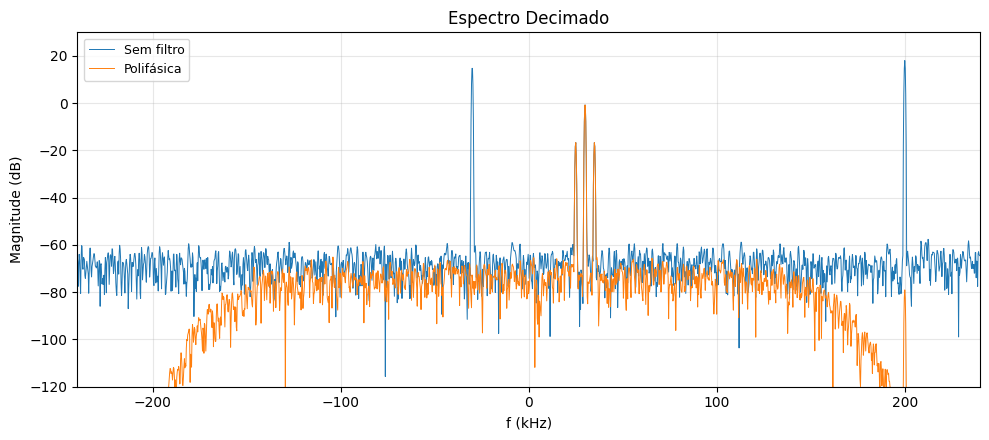

Alias (em -30 kHz) : -71.86 dB
Adjacente (200 kHz): -78.20 dB


In [11]:
hp    = np.concatenate([h, np.zeros((-len(h)) % D)])
y_pol = np.zeros(len(x)//D, dtype=complex)

for p in range(D):
    sub = hp[p::D]                                          
    xp  = np.concatenate([np.zeros(p, dtype=complex), x])[:len(x)][::D]
    c   = np.convolve(xp, sub)[:len(y_pol)]
    y_pol[:len(c)] += c
    
print(f"Erro máximo                : {np.max(np.abs(y_dir[:len(y_pol)] - y_pol)):.2e}")
print(f"Multiplicações (Direta)    : {M*D}")
print(f"Multiplicações (Polifásica): {len(hp)}")
print(f"Ganho de eficiência        : {M*D/len(hp):.1f}x")

#Verificação no espectro decimado
f_pol, X_pol = espectro(y_pol, Fs2, ntr)
u_pol = nivel(f_pol, X_pol, 30e3)

fig, ax = plt.subplots(figsize=(10, 4.5))

# Plot limpo mantendo apenas as curvas e a legenda básica
ax.plot(f_sem/1e3, 20*np.log10(X_sem/ref + 1e-300), lw=.7, label='Sem filtro')
ax.plot(f_pol/1e3, 20*np.log10(X_pol/ref + 1e-300), lw=.7, label='Polifásica')

ax.set_xlim(-240, 240)
ax.set_ylim(-120, 30)
ax.set_title('Espectro Decimado')
ax.set_xlabel('f (kHz)')
ax.set_ylabel('Magnitude (dB)')
ax.legend(fontsize=9)
ax.grid(alpha=.3)

plt.tight_layout()
plt.show()

print(f"Alias (em -30 kHz) : {20*np.log10(nivel(f_pol, X_pol, -30e3)/u_pol):+.2f} dB")
print(f"Adjacente (200 kHz): {20*np.log10(nivel(f_pol, X_pol, 200e3)/u_pol):+.2f} dB")

##### Comparação com um IIR

Base numérica para a última parte da questão conceitual: um IIR elíptico é projetado para as **mesmas**
especificações do FIR e as duas respostas são comparadas em magnitude, fase e atraso de grupo.

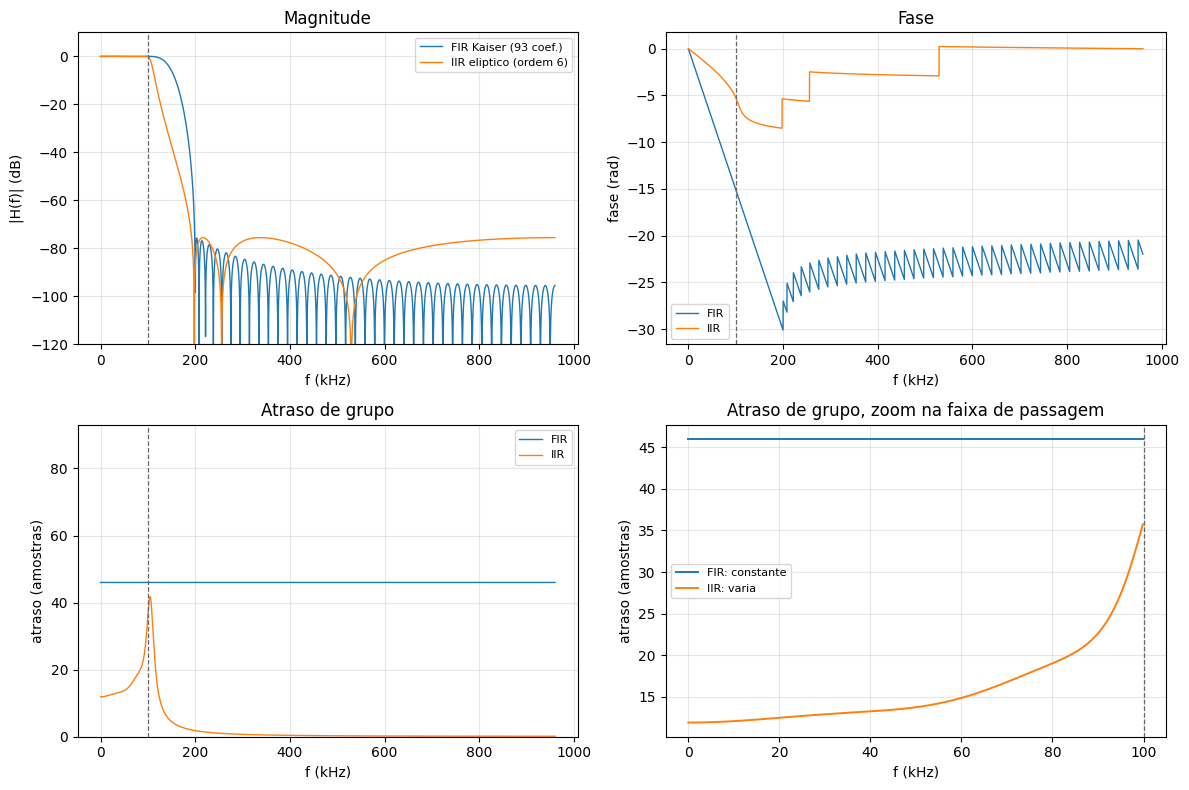

--- Comparação: FIR vs IIR ---
Complexidade FIR   : 93 coeficientes
Complexidade IIR   : Ordem 6 (3 seções SOS)

--- Atraso de grupo (Passagem) ---
Variação FIR       : 0.00 amostras
Variação IIR       : 23.86 amostras (12.42 us)

--- Multiplicações por saída ---
FIR Polifásico     : 96
IIR (Tradicional)  : 60


In [12]:
from scipy import signal

# IIR eliptico projetado para as MESMAS especificacoes do FIR.
# o scipy normaliza a frequencia pela Nyquist (Fs/2), nao por Fs
wp_n = fp/(Fs/2)
ws_n = fr/(Fs/2)
N_iir, Wn    = signal.ellipord(wp_n, ws_n, op, A)   # menor ordem que atende
b_iir, a_iir = signal.ellip(N_iir, op, A, Wn)

# resposta dos dois filtros na mesma grade de frequencias
fg2   = np.linspace(1.0, Fs/2, 4000)
wrad  = 2*np.pi*fg2/Fs
H_fir = Hd(fg2)
_, H_iir  = signal.freqz(b_iir, a_iir, worN=wrad)
_, gd_fir = signal.group_delay((h, 1),         w=wrad)
_, gd_iir = signal.group_delay((b_iir, a_iir), w=wrad)
pb2 = fg2 <= fp

fig, ax = plt.subplots(2, 2, figsize=(12, 8))

ax[0,0].plot(fg2/1e3, 20*np.log10(np.abs(H_fir) + 1e-300), lw=1, label=f'FIR Kaiser ({M} coef.)')
ax[0,0].plot(fg2/1e3, 20*np.log10(np.abs(H_iir) + 1e-300), lw=1, label=f'IIR eliptico (ordem {N_iir})')
ax[0,0].set_title('Magnitude'); ax[0,0].set_ylabel('|H(f)| (dB)'); ax[0,0].set_ylim(-120, 10)

ax[0,1].plot(fg2/1e3, np.unwrap(np.angle(H_fir)), lw=1, label='FIR')
ax[0,1].plot(fg2/1e3, np.unwrap(np.angle(H_iir)), lw=1, label='IIR')
ax[0,1].set_title('Fase'); ax[0,1].set_ylabel('fase (rad)')

ax[1,0].plot(fg2/1e3, gd_fir, lw=1, label='FIR')
ax[1,0].plot(fg2/1e3, gd_iir, lw=1, label='IIR')
ax[1,0].set_title('Atraso de grupo'); ax[1,0].set_ylabel('atraso (amostras)')
ax[1,0].set_ylim(0, M)

ax[1,1].plot(fg2[pb2]/1e3, gd_fir[pb2], lw=1.4, label='FIR: constante')
ax[1,1].plot(fg2[pb2]/1e3, gd_iir[pb2], lw=1.4, label='IIR: varia')
ax[1,1].set_title('Atraso de grupo, zoom na faixa de passagem')
ax[1,1].set_ylabel('atraso (amostras)')

for a_ in ax.ravel():
    a_.axvline(fp/1e3, ls='--', c='0.4', lw=.9)   # borda da passagem
    a_.set_xlabel('f (kHz)'); a_.grid(alpha=.3); a_.legend(fontsize=8)

plt.tight_layout(); plt.show()

var_fir = gd_fir[pb2].max() - gd_fir[pb2].min()
var_iir = gd_iir[pb2].max() - gd_iir[pb2].min()
sos     = int(np.ceil(N_iir/2))

# Prints formatados e diretos (sem excessos)
print("--- Comparação: FIR vs IIR ---")
print(f"Complexidade FIR   : {M} coeficientes")
print(f"Complexidade IIR   : Ordem {N_iir} ({sos} seções SOS)")

print("\n--- Atraso de grupo (Passagem) ---")
print(f"Variação FIR       : {var_fir:.2f} amostras")
print(f"Variação IIR       : {var_iir:.2f} amostras ({var_iir/Fs*1e6:.2f} us)")

print("\n--- Multiplicações por saída ---")
print(f"FIR Polifásico     : {M + (-M) % D}")
print(f"IIR (Tradicional)  : {sos*5*D}")